## Data encoding: Improving model accuracy by adding categorical data as features

## Importing libraries and the dataset

In [1]:
# Importing libraries
from IPython.display import display, HTML
import warnings

import pandas as pd
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

display(HTML('<style>.container { width:90% !important; }</style>'))
warnings.filterwarnings("ignore")

In [2]:
# Importing data
df = pd.read_excel('hotels.xlsx')
df.head()

,Profit,Price in millions,Square meters,City
0,119000,21.88,3938,Berlin
1,250000,27.95,3986,München
2,250000,16.09,2574,Köln
3,145000,27.58,4155,München
4,110000,23.76,3795,Berlin


In [3]:
# Missing values?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Profit             150 non-null    int64  
 1   Price in millions  150 non-null    float64
 2   Square meters      150 non-null    int64  
 3   City               150 non-null    object 
dtypes: float64(1), int64(2), object(1)
memory usage: 4.8+ KB


In [4]:
# Statistical information
df.describe()

,Profit,Price in millions,Square meters
count,150.000000,150.000000,150.000000
mean,106126.666667,17.101933,2594.680000
std,76413.507421,6.531691,1434.491133
min,2000.000000,4.160000,82.000000
25%,45500.000000,12.890000,1499.000000
50%,88500.000000,17.085000,2578.500000
75%,137750.000000,21.760000,3628.000000
max,250000.000000,35.350000,5741.000000


## Visualizing data

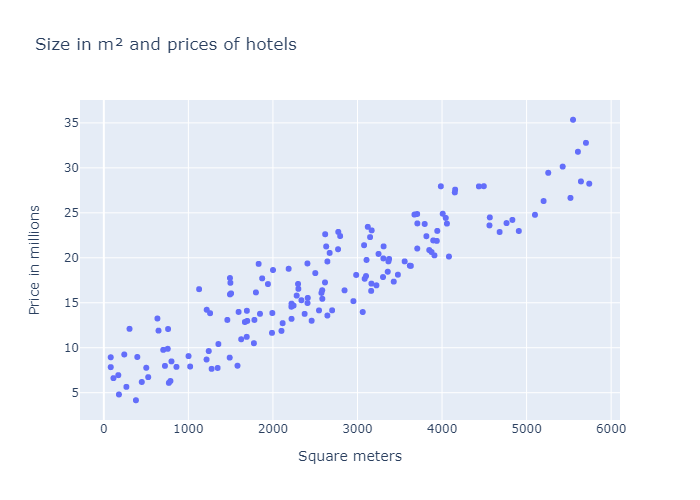

In [5]:
fig = px.scatter(df, x="Square meters", y="Price in millions", title="Size in m² and prices of hotels")
fig.show("png")

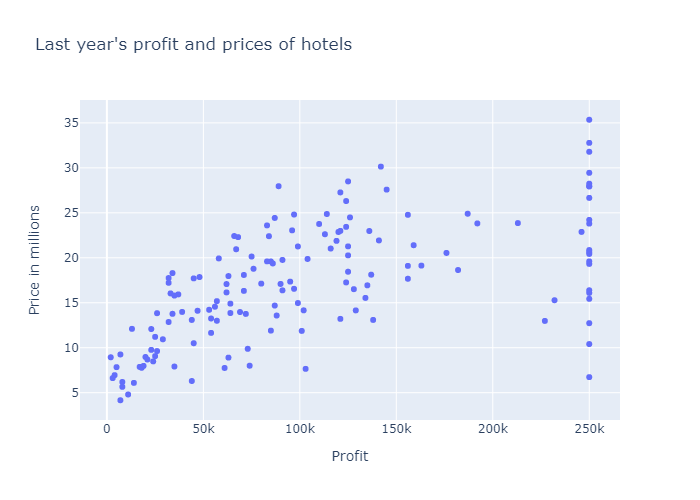

In [6]:
fig = px.scatter(df, x="Profit", y="Price in millions", title="Last year's profit and prices of hotels")
fig.show("png")

### Up until now, only numerical features were utilized for Linear Regression models. Using one-hot encoding, categorical features (in this example: city) can be utilized for model training. In the following code cells, 2 Linear Regression models will be trained and compared:
### Model 1: All input variables without cities | Model 2: All input variables with cities

## Model 1: All input variables without citites

In [7]:
# Generating an empty list
scores_without_cities = []

for i in range(0, 100):

    # Defining features
    X = df[['Square meters', 'Profit']]
    y = df[['Price in millions']]

    # Performing the train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

    # Instantiate model
    model = LinearRegression()

    # Train model
    model.fit(X_train, y_train)

    # Generating predictions
    y_pred = model.predict(X_test)

    # Output R² score
    r2 = r2_score(y_test, y_pred)
    scores_without_cities.append(r2)

print('Using all input variables without cities, the average R² score of 100 Linear Regression trainings is:', sum(scores_without_cities) / len(scores_without_cities))

Using all input variables without cities, the average R² score of 100 Linear Regression trainings is: 0.8286617420918355


## Model 2: All input variables with cities

In [8]:
# One-hot encoding the City column
df = pd.get_dummies(df, columns = ['City'], dtype=int)
df.head()

,Profit,Price in millions,Square meters,City_Berlin,City_Köln,City_München
0,119000,21.88,3938,1,0,0
1,250000,27.95,3986,0,0,1
2,250000,16.09,2574,0,1,0
3,145000,27.58,4155,0,0,1
4,110000,23.76,3795,1,0,0


In [9]:
# Generating an empty list
scores_with_cities = []

for i in range(0, 100):

    # Defining features
    X = df[['Square meters', 'City_Berlin', 'City_Köln']]
    y = df[['Price in millions']]

    # Performing the train test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

    # Instantiate model
    model = LinearRegression()

    # Train model
    model.fit(X_train, y_train)

    # Generating predictions
    y_pred = model.predict(X_test)

    # Output R² score
    r2 = r2_score(y_test, y_pred)
    scores_with_cities.append(r2)

print('Using all input variables with cities, the average R² score of 100 Linear Regression trainings is:', sum(scores_with_cities) / len(scores_with_cities))

Using all input variables with cities, the average R² score of 100 Linear Regression trainings is: 0.9626226401071776


## Conclusion:

## One-hot encoding categorical variables can help to improve model accuracy which results in better predictions for the price.